# House Prices - Advanced Regression Techniques
Hello everyone! In this notebook we are going to predict House Prices using sklearn library to solve regression task.


For this notebook **I would like to say thank you some authors for their notebooks that have inspired me to write own notebook**:
1. [PEDRO MARCELINO, PHD. Comprehensive data exploration with Python ](https://www.kaggle.com/pmarcelino/comprehensive-data-exploration-with-python)
2. [SERIGNE. Stacked Regressions : Top 4% on LeaderBoard](https://www.kaggle.com/serigne/stacked-regressions-top-4-on-leaderboard)
3. [PRADNESH LACHAKE. Multiple Linear Regression and Regularization](https://www.kaggle.com/pradneshlachake/multiple-linear-regression-and-regularization)


# 1. Import libraries
For regression task we are going to use [sklearn](https://scikit-learn.org/stable/) library.


In [1]:
import math
import random
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


from scipy import stats
from scipy.stats import norm, skew 


import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import explained_variance_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, \
                                 RidgeCV, Lasso, LassoCV, \
                                 ElasticNet, ElasticNetCV

# 2. Read data
Here we read train and test sets.

In [2]:
df_train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv', header = 0)
df_test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

In [3]:
df_train.head(5) # look for train first 5 rows

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_test.head(5) # look for test first 5 rows

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
print(df_train.shape)
print(df_test.shape)

(1460, 81)
(1459, 80)


# 2. Visualize data

# 2.1. the relation between target column and some other columns

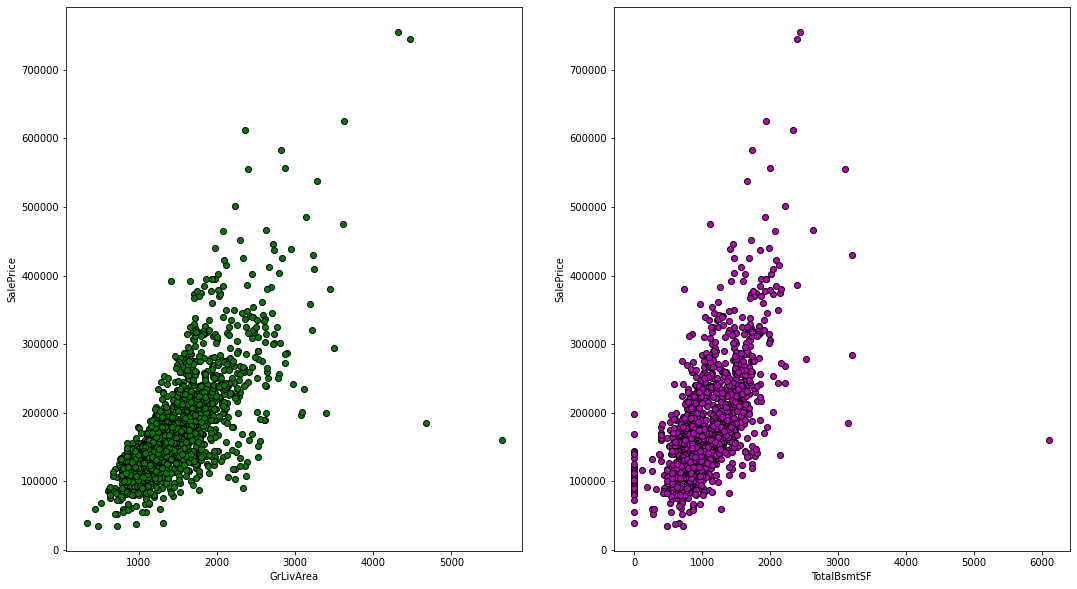

In [6]:
fig = plt.figure(figsize = (18,10))

fig.add_subplot(121)
plt.scatter(x = df_train['GrLivArea'], y = df_train['SalePrice'], color = "g", edgecolor = 'k')
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

fig.add_subplot(122)
plt.scatter(x = df_train['TotalBsmtSF'], y = df_train['SalePrice'], color = "m", edgecolor = 'k')
plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")

plt.show()

So, here we can see the relationship of **'SalePrice'** with **'GrLivArea'** and **'TotalBsmtSF'**. The first one looks like linear dependency and the second one is like exponential (or also linear).

# 2.2. distribution of target 'SalePrice' variable

Firstly, let's apply **describe()** method to look through the statistics.

In [7]:
stats = df_train['SalePrice'].describe()
stats

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

After that, we can plot the distribution of the target variable.

In [8]:
def plot_distribution(df):
    fig = plt.figure(figsize = (20,10))
    df['SalePrice'].plot.kde(color = 'r')
    df['SalePrice'].plot.hist(density = True, color = 'blue', edgecolor = 'k', bins = 100)
    plt.legend(['Normal distibution, ($\mu =${:.2f} and $\sigma =${:.2f})'.format(stats[1], stats[2])], loc='best')
    plt.title("Frequency distribution plot")
    plt.xlabel("SalePrice")
    # I don't like "1e6" number notation, so style will be 'plain'
    plt.ticklabel_format(style = 'plain', axis = 'y') 
    plt.ticklabel_format(style = 'plain', axis = 'x') 
    plt.show()


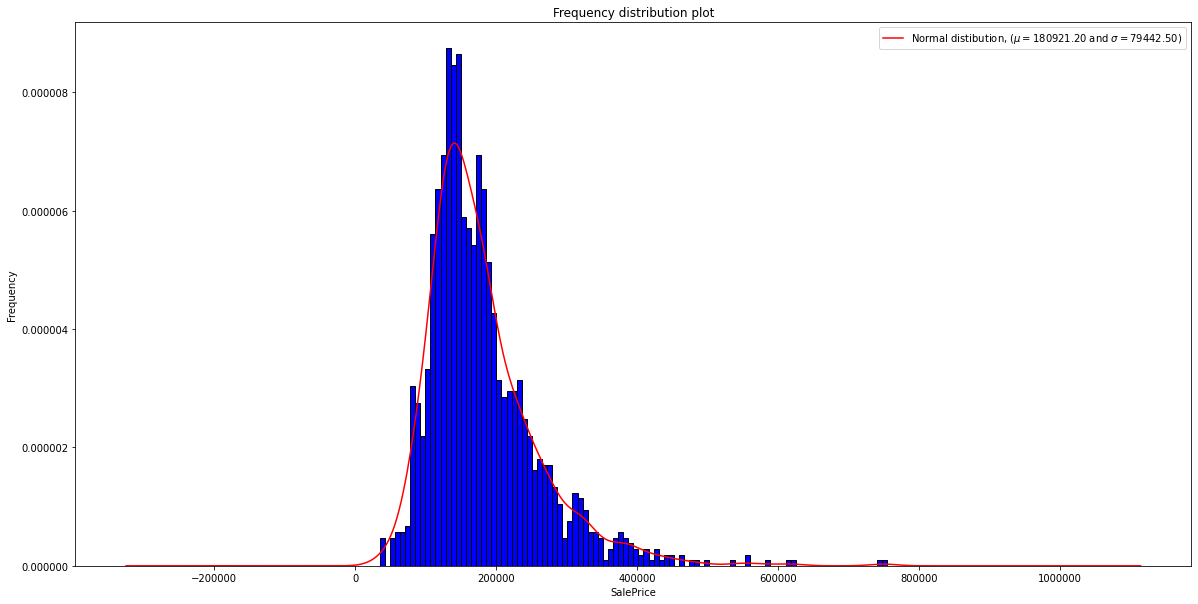

In [9]:
plot_distribution(df_train)

As the [evaluation](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview/evaluation) of the code needs to be converted to log, we'll apply it to our target variable:
*Taking logs means that errors in predicting expensive houses and cheap houses will affect the result equally*. It is explained that the target variable is right skewed. As linear models like normally distributed data, we need to transform this variable and make it more normally distributed.

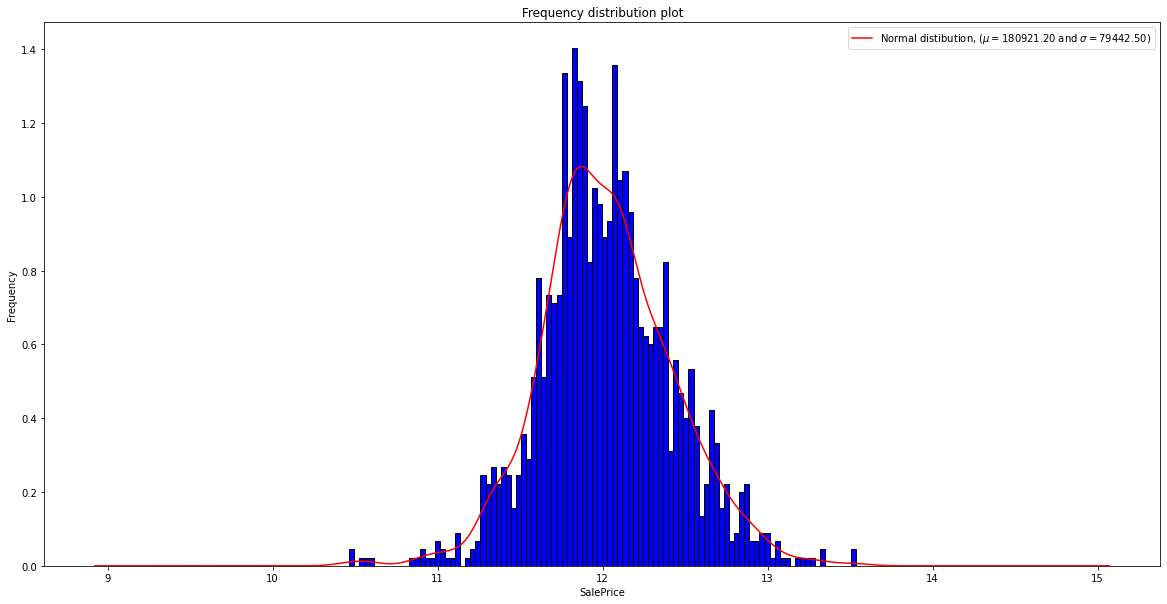

In [10]:
df_train["SalePrice"] = np.log1p(df_train["SalePrice"])
plot_distribution(df_train)

# 2.3. correlation between variables
Here we calculate the correlation bewween variables.

In [11]:
cor_matrix = df_train.corr()
cor_matrix.style.background_gradient(cmap='coolwarm')

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,-0.005968,-0.007940,-0.015415,0.010496,0.005590,-0.044230,0.008273,0.002289,-0.020155,0.005587,0.006784,0.037719,0.002951,0.027239,-0.019772,0.000072,0.016570,0.017634,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.017942
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,-0.140759,-0.238518,-0.251758,0.307886,0.046474,0.074853,0.003491,-0.002333,0.131608,0.177354,-0.023438,0.281721,0.040380,-0.045569,0.085072,-0.040110,-0.098672,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.073959
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,0.132644,0.392075,0.457181,0.080177,0.038469,0.402797,0.100949,-0.007234,0.198769,0.053532,0.263170,-0.006069,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.355879
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,-0.002618,0.260833,0.299475,0.050986,0.004779,0.263116,0.158155,0.048046,0.126031,0.014259,0.119690,-0.017784,0.190015,0.271364,-0.024947,0.154871,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.257320
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,0.308159,0.537808,0.476224,0.295493,-0.030429,0.593007,0.111098,-0.040150,0.550600,0.273458,0.101676,-0.183882,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.817185
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,-0.136841,-0.171098,-0.144203,0.028942,0.025494,-0.079686,-0.054942,0.117821,-0.194149,-0.060769,0.012980,-0.087001,-0.057583,-0.023820,-0.324297,-0.185758,-0.151521,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.036868
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,0.149040,0.391452,0.281986,0.010308,-0.183784,0.199010,0.187599,-0.038162,0.468271,0.242656,-0.070651,-0.174800,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.586570
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,0.181133,0.291066,0.240379,0.140024,-0.062419,0.287389,0.119470,-0.012337,0.439046,0.183331,-0.040581,-0.149598,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.565608
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,0.114442,0.363936,0.344501,0.174561,-0.069071,0.390857,0.085310,0.026673,0.276833,0.201444,0.102821,-0.037610,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.430809
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,-0.495251,0.522396,0.445863,-0.137079,-0.064503,0.208171,0.649212,0.067418,0.058543,0.004262,-0.107355,-0.081007,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,-0.102303,0.026451

And, for better unstanding, we can separate the correlation between the target variable and other variables for the better visualizing.

In [12]:
cor_matrix2 = cor_matrix["SalePrice"]
cor_matrix2 = cor_matrix2.to_frame()
cor_matrix2.style.background_gradient(cmap='coolwarm')

,SalePrice
Id,-0.017942
MSSubClass,-0.073959
LotFrontage,0.355879
LotArea,0.257320
OverallQual,0.817185
OverallCond,-0.036868
YearBuilt,0.586570
YearRemodAdd,0.565608
MasVnrArea,0.430809
BsmtFinSF1,0.372023


# 2.4. pairplots

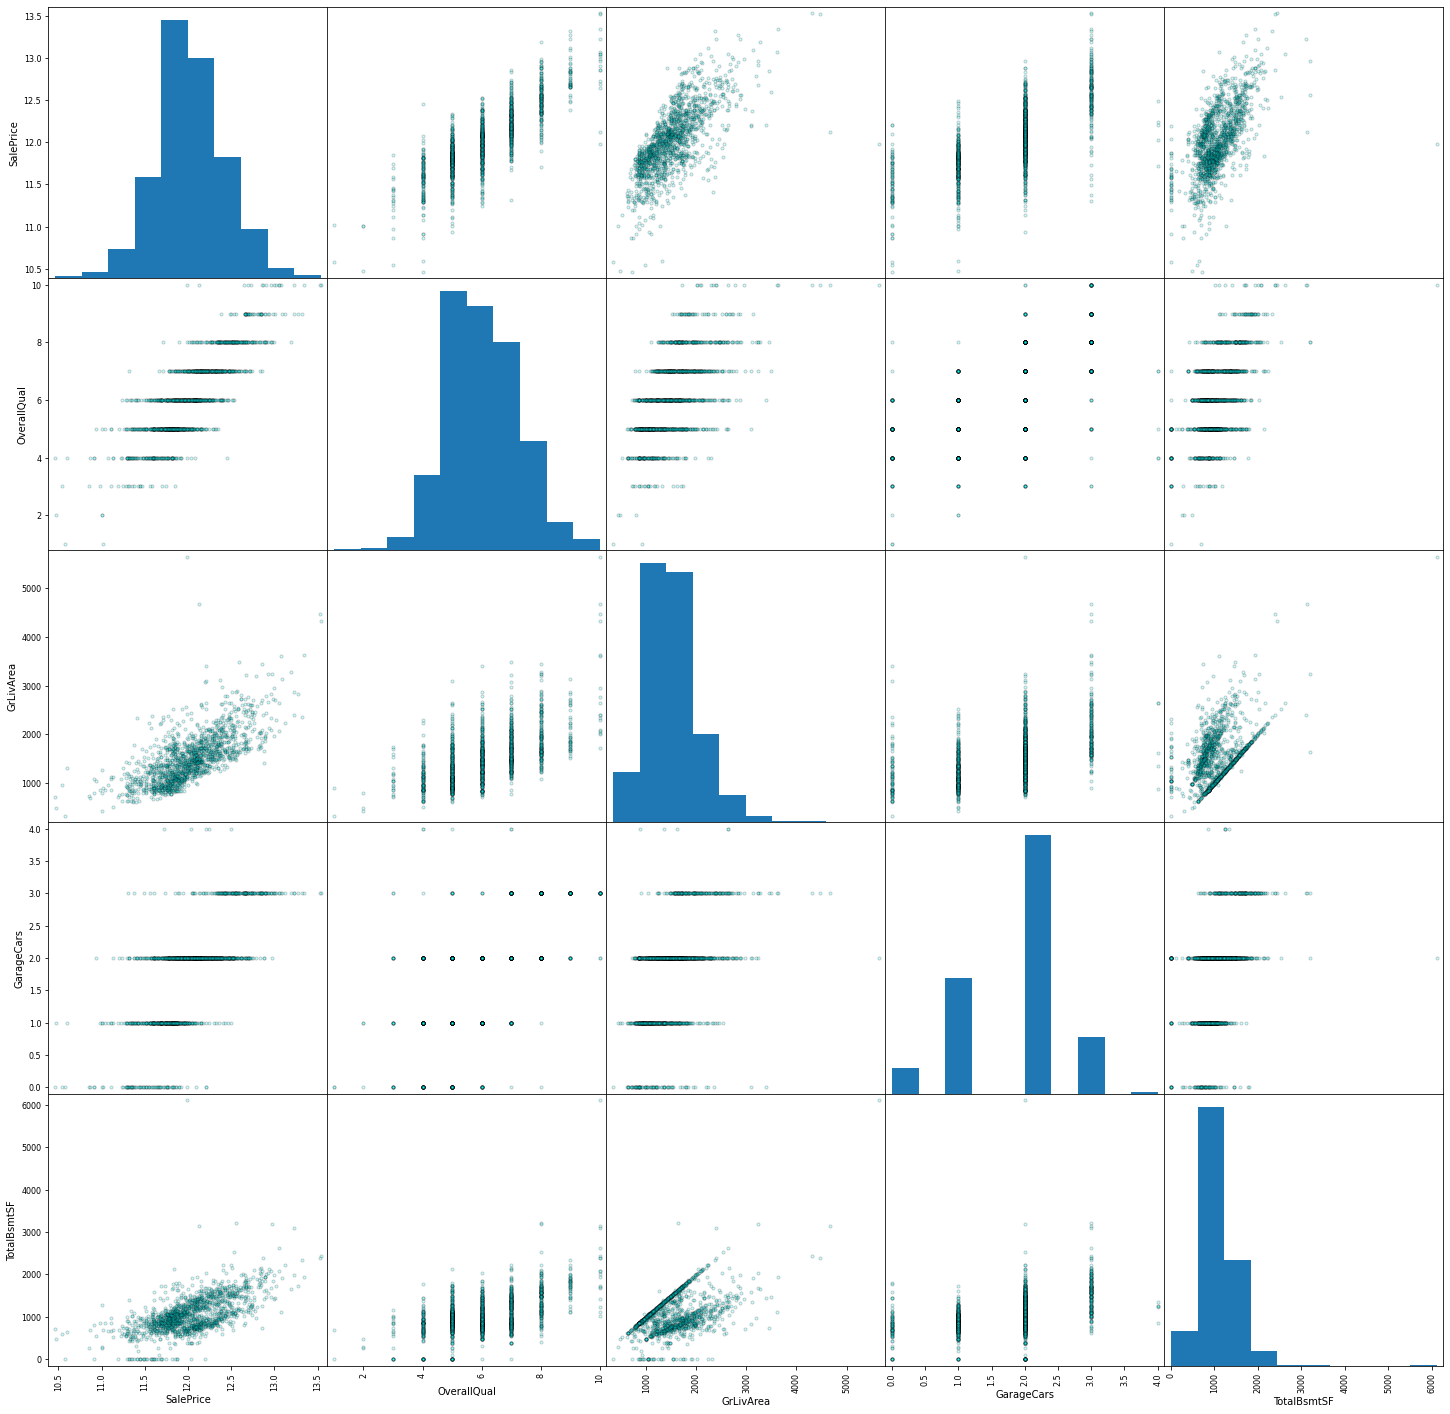

In [13]:
# choosing some columns for plotting pairplots
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']
pd.plotting.scatter_matrix(df_train[cols], alpha=0.2, figsize=(25, 25), color = 'cyan', edgecolor='k')
plt.show()

# 3. Delete NaNs
We can check dataframe for missing data (NaNs).

In [14]:
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'InPercents'])
missing_data.head(35).style.background_gradient(cmap='autumn')

,Total,InPercents
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
GarageCond,81,0.055479
GarageType,81,0.055479
GarageFinish,81,0.055479


Let's analyse this to understand how to handle the missing data. I'll consider that when more than 8 elements of the data is missing, I will delete the corresponding variable. According to the results above, cells that will be deleted are: 'BsmtFinType1', 'BsmtCond', ..., 'MiscFeature' and 'PoolQC'. And the point is: will we miss this data? I think no, because I don't think that these variables are vety important (in other case, I don't think that there wiuld be so much missing data in important variables).

In [15]:
# choosing data, where missed more, than 8 cells
mask = (missing_data["Total"] > 8)
missing_data = missing_data.loc[mask]

# dropping these columns from original datasets
df_train = df_train.drop(columns = missing_data.index)
df_test = df_test.drop(columns = missing_data.index)

# fill NaNs with "Unknown"
df_train = df_train.fillna("Unknown") 
df_test = df_test.fillna("Unknown") 

print(df_train.shape)
print(df_test.shape)

(1460, 65)
(1459, 64)


And other NaNs we will replace with **mode** of the column.

In [16]:
# fill other NaNs with mode
for col in df_train: 
    df_train[col] = df_train[col].replace("Unknown",df_train[col].mode()[0])
for col in df_test:
    df_test[col] = df_test[col].replace("Unknown",df_test[col].mode()[0])
    
print(df_train.shape)
print(df_test.shape)

(1460, 65)
(1459, 64)


And here we have the final check of the NaNs. The 'Total' column must have 0 in each cell.

In [17]:
# check missing data in df_train after working with missed values
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'InPercents'])
missing_data.head(5).style.background_gradient(cmap='autumn')

,Total,InPercents
Id,0,0.000000
HeatingQC,0,0.000000
Electrical,0,0.000000
1stFlrSF,0,0.000000
2ndFlrSF,0,0.000000


In [18]:
df_train.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotArea            int64
Street            object
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice        float64
Length: 65, dtype: object

# 4. Feature engineering
Now it's time to prepare data before we will train our regression models. Firstly, let's convert some obvious variables (like 'MoSold') to categorical type. We will make it by convertring data to **"str" type.**

In [19]:
# convert some vars to categorical features
def convert_to_categorical(df):
    df['MSSubClass'] = df['MSSubClass'].apply(str)
    df['OverallCond'] = df['OverallCond'].astype(str)
    # df['YrSold'] = df['YrSold'].astype(str)
    df['MoSold'] = df['MoSold'].astype(str)
    
convert_to_categorical(df_train)
convert_to_categorical(df_test)

print(df_train.shape)
print(df_test.shape)

(1460, 65)
(1459, 64)


For training data, we don't need 'SalePrice', because it is the tagret variable. In addition, we don't need the 'Id' column, because it doesn't influence on the inner properties of the house (like size, color, etc), it is just the number of the house in the dataset.

In [20]:
y_train = df_train["SalePrice"].copy()
x_train = df_train.copy().drop(columns = ["Id", "SalePrice"])
x_test = df_test.copy().drop(columns = ["Id"])

print(x_train.shape)
print(x_test.shape)

(1460, 63)
(1459, 63)


In [21]:
x_train.head() # check train data

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,0,5,2007,WD,Normal
2,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,42,0,0,0,0,0,9,2008,WD,Normal
3,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,35,272,0,0,0,0,2,2006,WD,Abnorml
4,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,84,0,0,0,0,0,12,2008,WD,Normal


In [22]:
x_test.head() # check test data

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,0,0,0,120,0,0,6,2010,WD,Normal
1,20,RL,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,...,36,0,0,0,0,12500,6,2010,WD,Normal
2,60,RL,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,...,34,0,0,0,0,0,3,2010,WD,Normal
3,60,RL,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,...,36,0,0,0,0,0,6,2010,WD,Normal
4,120,RL,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,StoneBr,...,82,0,0,144,0,0,1,2010,WD,Normal


After that, we need to label our string data. We will apply one-hot encoding - **pd.dummies()**, to the categorical variables.

P.S. categorical variables has **'np.object' type**. It is the complex type of the variable.

In [23]:
x_all = pd.concat([x_train, x_test])
categorical_cols = x_all.select_dtypes(include=np.object).columns
x_all = pd.get_dummies(x_all, prefix=categorical_cols)

x_train = x_all[:len(x_train)]
x_test = x_all[len(x_train):]

print(x_train.shape)


(1460, 259)


# 5. Normalize data
We will apply min-max normalization in range [0,1].

In [24]:
scaler = MinMaxScaler(feature_range = (0, 1)) # range is [0, 1]

Here we normalize train set.

In [25]:
normed = scaler.fit_transform(x_train.copy())
x_train = pd.DataFrame(data=normed, columns=x_train.columns)
x_train.head() # check the result

,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.033420,0.666667,0.949275,0.883333,0.12250,0.125089,0.0,0.064212,0.140098,0.119780,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.038795,0.555556,0.753623,0.433333,0.00000,0.173281,0.0,0.121575,0.206547,0.212942,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.046507,0.666667,0.934783,0.866667,0.10125,0.086109,0.0,0.185788,0.150573,0.134465,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.038561,0.666667,0.311594,0.333333,0.00000,0.038271,0.0,0.231164,0.123732,0.143873,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.060576,0.777778,0.927536,0.833333,0.21875,0.116052,0.0,0.209760,0.187398,0.186095,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


And here we normalize test set.

In [26]:
normed = scaler.fit_transform(x_test.copy())
x_test = pd.DataFrame(data=normed, columns=x_test.columns)
x_test.head() # check the result

,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.184147,0.444444,0.625954,0.183333,0.000000,0.116708,0.094364,0.126168,0.173111,0.104309,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.232124,0.555556,0.603053,0.133333,0.083721,0.230175,0.000000,0.189720,0.260844,0.196672,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.224197,0.444444,0.900763,0.800000,0.000000,0.197257,0.000000,0.064019,0.182139,0.111135,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.154326,0.555556,0.908397,0.800000,0.015504,0.150125,0.000000,0.151402,0.181747,0.110708,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.064121,0.777778,0.862595,0.700000,0.000000,0.065586,0.000000,0.475234,0.251227,0.186220,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# 6. Machine learning (regression)
Here we will apply [sklearn linear models](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model) to regression task. 

In [27]:
all_regr_models = [
    LinearRegression(),
    Ridge(), 
    RidgeCV(),
    LassoCV(max_iter=100000),
    ElasticNetCV()  
]

In [28]:
# there we will store RMSEs
all_rmse_train = {}

# there we will store accuracies
all_acc_train = {}

In [29]:
# learn all regressors, write accuracy and save trained models in pickle-format
for model in all_regr_models:
    
    # get the regressor name 
    model_name = model.__class__.__name__ 
    print("♦ ", model_name)
    
    # train model
    model.fit(x_train, y_train)
    
    # calculate rmse on train set
    y_train_pred = model.predict(x_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = math.sqrt(mse_train)
    print("- rmse_train =", round(rmse_train,7))
    
    # calculate model accuracy on train set
    model_acc_train = explained_variance_score(y_train, y_train_pred)
    print("- model_acc_train =", round(model_acc_train,7))
    
    # save its rmse on train set
    all_rmse_train[model_name] = rmse_train
    all_acc_train[model_name] = model_acc_train
    
    # predict data on test set (result variable for competition)
    y_test_pred_log1p = model.predict(x_test)
    y_test_pred = np.expm1(y_test_pred_log1p)
    
    # save model
    filename = model_name + '_model.pickle'
    pickle.dump(model, open(filename, 'wb'))  
    
    # # load model
    # loaded_model = pickle.load(open(filename, 'rb'))
    # result = loaded_model.score(x_train, y_train)     
    
    
    # submit prediction for competition
    if (model_name == 'LassoCV'):
        submission = pd.DataFrame({'Id': df_test['Id'], 'SalePrice': y_test_pred})
        submission.to_csv('submission.csv', index=False)
        print('! submission is successful')
        
    print()
    

♦  LinearRegression
- rmse_train = 0.0957145
- model_acc_train = 0.9425447

♦  Ridge


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: overflow encountered in expm1


- rmse_train = 0.1026801
- model_acc_train = 0.9338779

♦  RidgeCV
- rmse_train = 0.1181577
- model_acc_train = 0.9124415

♦  LassoCV
- rmse_train = 0.1113647
- model_acc_train = 0.9222198
! submission is successful

♦  ElasticNetCV
- rmse_train = 0.1120432
- model_acc_train = 0.9212691



As we can see, the best results were shown by LinearRegression and LassoCV. I decided to save LassoCV results as my submition (because for LinearRegression I achieved ~ 0.14 RMSE for test set in the Leaderboard and for LassoCV I achieved ~0.13 RMSE).

# 7. Visualize results

In [30]:
def visualize_results(fig, subplot_id, sort_order, all_list, color_map, title, y_label):
    # sort from biggest to smallest
    all_list = dict(sorted(all_list.items(), key=lambda item: item[1], reverse=sort_order))

    # get keys and values as parameters to build plot
    keys = all_list.keys()
    values = all_list.values()

    # color map for bar chart
    color = color_map(np.linspace(0, 1, len(keys)))

    # plot
    fig.add_subplot(subplot_id)
    plt.title(title)
    plt.xlabel('regressors')
    plt.ylabel(y_label)
    plt.bar(keys, values, color=color)
    plt.xticks(rotation = 'vertical')


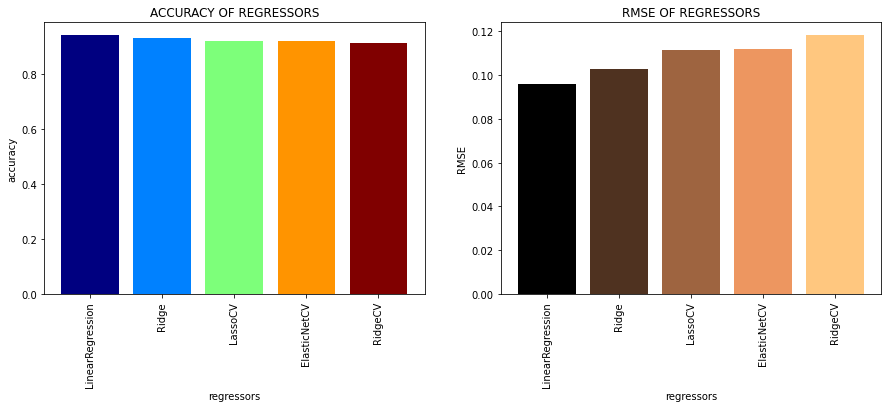

In [31]:
fig = plt.figure(figsize=(15, 5))
visualize_results(fig, 121, True, all_acc_train, plt.cm.jet, 'ACCURACY OF REGRESSORS', 'accuracy')
visualize_results(fig, 122, False, all_rmse_train, plt.cm.copper, 'RMSE OF REGRESSORS', 'RMSE')
plt.show()

# 7. Conclusion
Thank you for reading my new article! Hope, you liked it and it was interesting for you! There are some more my articles:
* [Automobile Customer Clustering (K-means & PCA)](https://www.kaggle.com/maricinnamon/automobile-customer-clustering-k-means-pca)
* [Credit Card Fraud detection sklearn](https://www.kaggle.com/maricinnamon/credit-card-fraud-detection-sklearn)
* [Market Basket Analysis for beginners](https://www.kaggle.com/maricinnamon/market-basket-analysis-for-beginners)
* [Neural Network for beginners with keras](https://www.kaggle.com/maricinnamon/neural-network-for-beginners-with-keras)
* [Fetal Health Classification for beginners sklearn](https://www.kaggle.com/maricinnamon/fetal-health-classification-for-beginners-sklearn)
* [Retail Trade Report Department Stores (LSTM)](https://www.kaggle.com/maricinnamon/retail-trade-report-department-stores-lstm)